# Sree Ram Roshan A S - 24BAD113

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sreeramroshanas/experiment-6/fraud_smote.csv
/kaggle/input/datasets/sreeramroshanas/experiment-6/diabetes_bagging.csv
/kaggle/input/datasets/sreeramroshanas/experiment-6/churn_boosting.csv
/kaggle/input/datasets/sreeramroshanas/experiment-6/heart_stacking.csv
/kaggle/input/datasets/sreeramroshanas/experiment-6/income_random_forest.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

# SCENARIO 1 — BAGGING (Diabetes)

In [7]:
df = pd.read_csv('/kaggle/input/datasets/sreeramroshanas/experiment-6/diabetes_bagging.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        120 non-null    int64  
 1   BMI            120 non-null    float64
 2   Age            120 non-null    int64  
 3   BloodPressure  120 non-null    int64  
 4   Insulin        120 non-null    int64  
 5   Outcome        120 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 5.8 KB
None
          Glucose         BMI         Age  BloodPressure     Insulin  \
count  120.000000  120.000000  120.000000     120.000000  120.000000   
mean   138.7333

In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [10]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

In [11]:
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

print("\nBagging Classification Report:\n", classification_report(y_test, y_pred_bag))

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0

Bagging Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        18

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



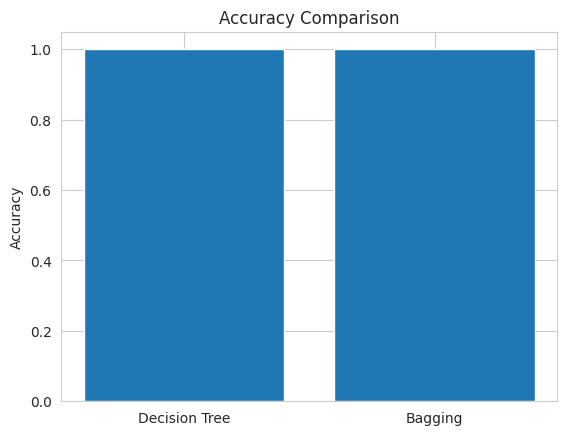

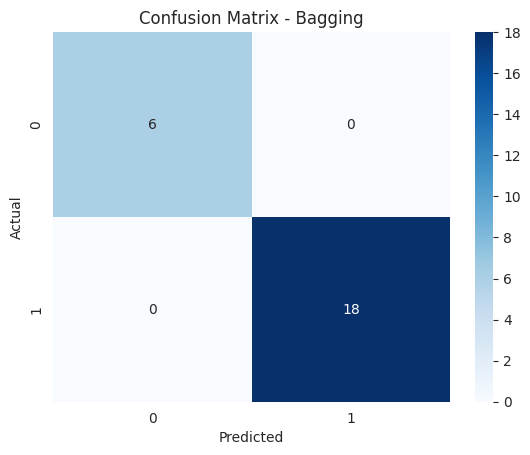

In [12]:
plt.bar(['Decision Tree','Bagging'], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Bagging")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SCENARIO 2 — BOOSTING (Churn)

In [13]:
df = pd.read_csv('/kaggle/input/datasets/sreeramroshanas/experiment-6/churn_boosting.csv')

print(df.head())
print(df.info())

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tenure           120 non-null    int64  
 1   MonthlyCharges   120 non-null    float64
 2   ContractType     120 non-null    object 
 3   InternetService  77 non-null     object 
 4   Churn            120 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 4.8+ KB
None


In [14]:
ada = AdaBoostClassifier(n_estimators=100)
gb = GradientBoostingClassifier(n_estimators=100)

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [15]:
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

AdaBoost Accuracy: 0.875
Gradient Boosting Accuracy: 0.9583333333333334


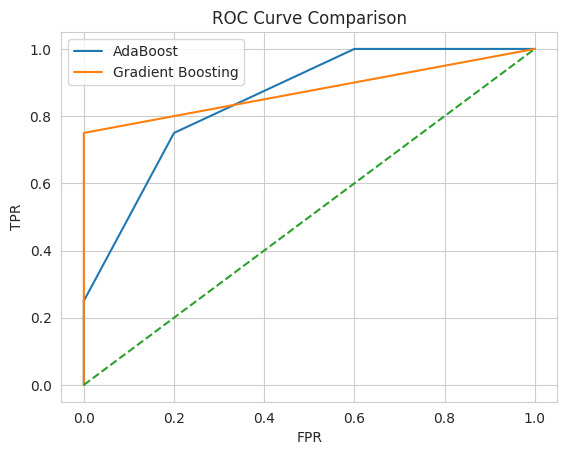

In [17]:
fpr1, tpr1, _ = roc_curve(y_test, ada.predict_proba(X_test)[:,1])
fpr2, tpr2, _ = roc_curve(y_test, gb.predict_proba(X_test)[:,1])

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="Gradient Boosting")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

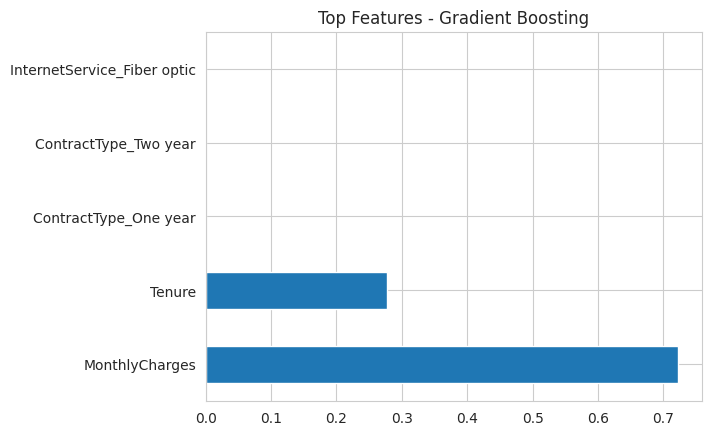

In [18]:
feat_imp = pd.Series(gb.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features - Gradient Boosting")
plt.show()

# SCENARIO 3 — RANDOM FOREST (Income)

In [23]:
df = pd.read_csv('/kaggle/input/datasets/sreeramroshanas/experiment-6/income_random_forest.csv')

print(df.head())

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Income', axis=1)
y = df['Income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1


In [20]:
trees = [10, 50, 100, 150]
acc = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    acc.append(accuracy_score(y_test, pred))

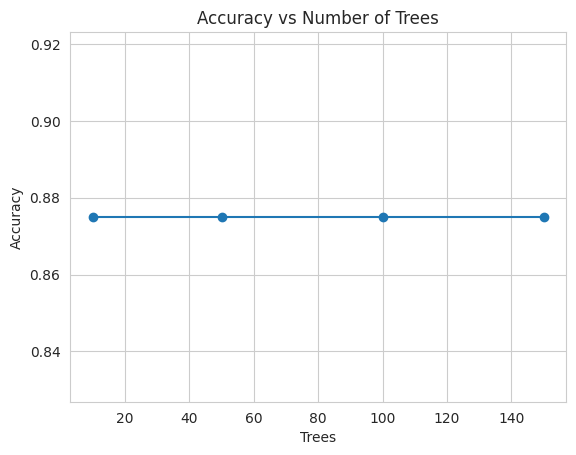

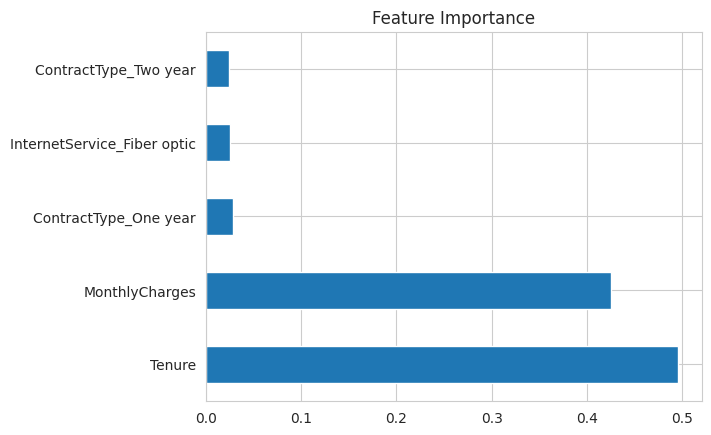

In [21]:
plt.plot(trees, acc, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Trees")
plt.ylabel("Accuracy")
plt.show()

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Feature Importance")
plt.show()

# SCENARIO 4 — STACKING (Heart)

In [25]:
df = pd.read_csv('/kaggle/input/datasets/sreeramroshanas/experiment-6/heart_stacking.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           120 non-null    int64
 1   Cholesterol   120 non-null    int64
 2   MaxHeartRate  120 non-null    int64
 3   RestingBP     120 non-null    int64
 4   HeartDisease  120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB
None
              Age  Cholesterol  MaxHeartRate   RestingBP  HeartDisease
count  120.000000    120.00000    120.000000  120.000000    120.000000
mean    52.791667    228.90000    140.733333  137.858333      0.691667

In [26]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
svm = SVC(probability=True)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "SVM": svm
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    
    print(f"{name} Accuracy:", acc)
    print(classification_report(y_test, pred))

Logistic Regression Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.56      0.71         9
           1       0.79      1.00      0.88        15

    accuracy                           0.83        24
   macro avg       0.89      0.78      0.80        24
weighted avg       0.87      0.83      0.82        24

Decision Tree Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.94      1.00      0.97        15

    accuracy                           0.96        24
   macro avg       0.97      0.94      0.95        24
weighted avg       0.96      0.96      0.96        24

SVM Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.56      0.71         9
           1       0.79      1.00      0.88        15

    accuracy                           0.83        24
   

In [28]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('dt', DecisionTreeClassifier()),
        ('svm', SVC(probability=True))
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
pred_stack = stack.predict(X_test)

stack_acc = accuracy_score(y_test, pred_stack)
results["Stacking"] = stack_acc

print("Stacking Accuracy:", stack_acc)
print(classification_report(y_test, pred_stack))

Stacking Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.94      1.00      0.97        15

    accuracy                           0.96        24
   macro avg       0.97      0.94      0.95        24
weighted avg       0.96      0.96      0.96        24



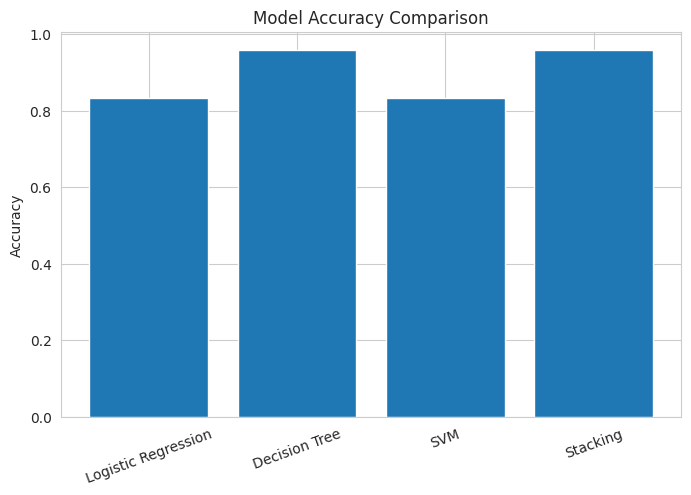

In [29]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

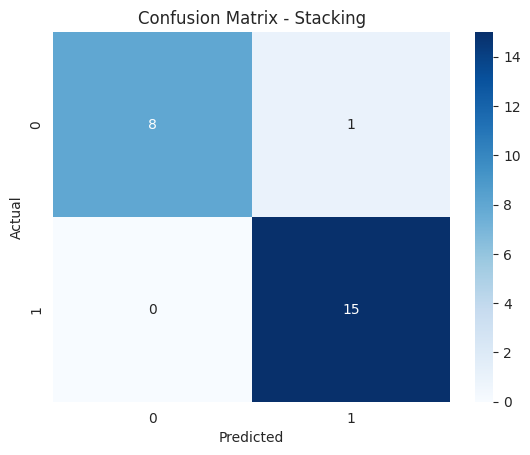

In [30]:
sns.heatmap(confusion_matrix(y_test, pred_stack), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Stacking")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SCENARIO 5 — SMOTE

In [31]:
df = pd.read_csv('/kaggle/input/datasets/sreeramroshanas/experiment-6/fraud_smote.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Amount    120 non-null    float64
 1   Time      120 non-null    int64  
 2   Feature1  120 non-null    float64
 3   Feature2  120 non-null    float64
 4   Fraud     120 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.8 KB
None
            Amount         Time    Feature1    Feature2       Fraud
count   120.000000    120.00000  120.000000  120.000000  120.000000
mean   2473.833250  46123.17500    0.092299    0.052550    0.083333
std    1315.748506  23677.66734    1.032644    1.023889    0.277544
min      13.920000   4438.

In [33]:
X = df.drop('Fraud', axis=1)
y = df['Fraud']

Fraud
0    110
1     10
Name: count, dtype: int64


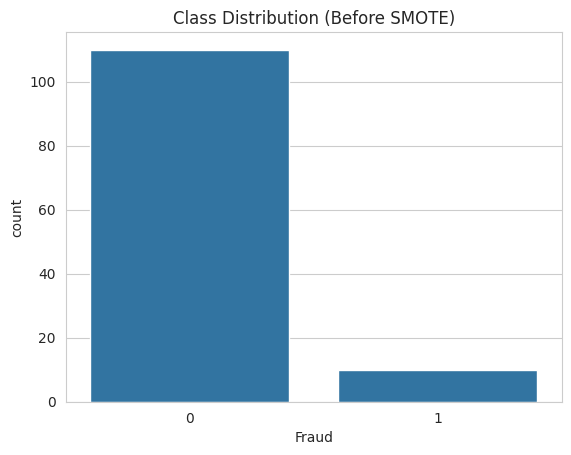

In [34]:
print(y.value_counts())

sns.countplot(x=y)
plt.title("Class Distribution (Before SMOTE)")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_before = RandomForestClassifier()
model_before.fit(X_train, y_train)

pred_before = model_before.predict(X_test)

print("Before SMOTE:\n")
print(classification_report(y_test, pred_before))

Before SMOTE:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fraud
0    110
1    110
Name: count, dtype: int64


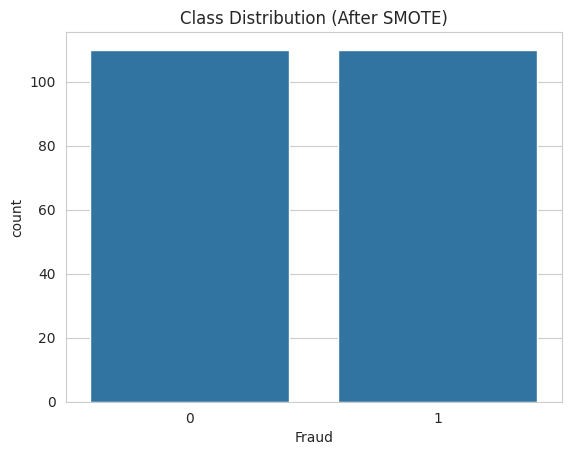

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(pd.Series(y_res).value_counts())

sns.countplot(x=y_res)
plt.title("Class Distribution (After SMOTE)")
plt.show()

In [37]:
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

model_after = RandomForestClassifier()
model_after.fit(X_train_res, y_train_res)

pred_after = model_after.predict(X_test_res)

print("After SMOTE:\n")
print(classification_report(y_test_res, pred_after))

After SMOTE:

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        24
           1       0.82      0.90      0.86        20

    accuracy                           0.86        44
   macro avg       0.86      0.87      0.86        44
weighted avg       0.87      0.86      0.86        44



In [38]:
acc_before = accuracy_score(y_test, pred_before)
acc_after = accuracy_score(y_test_res, pred_after)

print("Accuracy Before SMOTE:", acc_before)
print("Accuracy After SMOTE:", acc_after)

Accuracy Before SMOTE: 0.9166666666666666
Accuracy After SMOTE: 0.8636363636363636


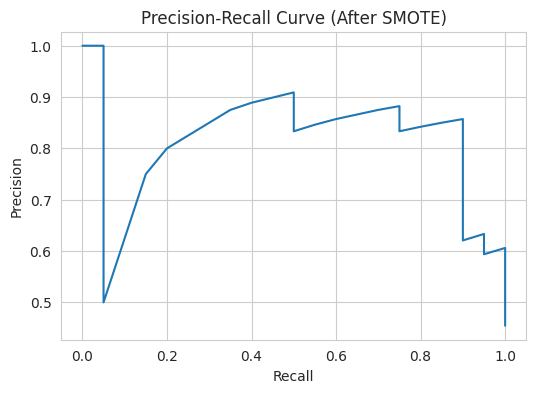

In [39]:
probs = model_after.predict_proba(X_test_res)[:,1]

precision, recall, _ = precision_recall_curve(y_test_res, probs)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (After SMOTE)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()